# **Data Augmentation**

In this notebook, we will demonstrate practical examples of all the data augmentation functions within BiaPy, including their parameters in both 2D and 3D. It is designed to be interactive, allowing the user to experiment with different values and functions.

**Contact:** This notebook was created by [Ibai Mayoral](https://github.com/ibai-0) and [Ignacio Arganda-Carreras](mailto:ignacio.arganda@ehu.eus). For suggestions, comments, or issues, please reach out to us via email or [create an issue in BiaPy's repository](https://github.com/BiaPyX/BiaPy/issues). Thank you!

---

## Available Transformations in BiaPy

The following image augmentation techniques are implemented to introduce biologically meaningful variability into microscopy datasets. These methods enhance model robustness by simulating different imaging conditions, tissue morphologies, and acquisition inconsistencies.

Each transformation is designed to preserve anatomical integrity while increasing the diversity of the training data.

- **Cutout**  
  Randomly masks out rectangular regions, simulating occlusions or tissue loss.

- **Cutblur**  
  Blurs a random region by downsampling and upsampling, mimicking local defocus or resolution loss.

- **Cutmix**  
  Patches a region from one image into another, simulating tissue grafts or mixed samples.

- **CutNoise**  
  Adds Gaussian noise to random regions, imitating localized sensor or acquisition noise.

- **Misalignment**  
  Introduces slice misalignments, replicating sectioning or registration errors in 3D stacks.

- **Brightness**  
  Adjusts image brightness, simulating variable illumination or staining.

- **Contrast**  
  Alters image contrast, reflecting differences in staining or imaging conditions.

- **Missing Sections**  
  Inserts black lines or missing regions, emulating lost or damaged tissue sections.

- **Shuffle Channels**  
  Randomly permutes image channels, testing model invariance to channel order.

- **GridMask**  
  Applies a grid-like mask, simulating structured occlusions or acquisition artifacts.

- **Random Rotation**  
  Rotates images by a random angle, simulating arbitrary sample orientation.

- **90° Rotation**  
  Rotates images by 90°, 180°, or 270°, introducing discrete orientation changes.

- **Zoom**  
  Scales images in or out, replicating changes in microscope magnification.

- **Gamma Contrast**  
  Adjusts contrast non-linearly, simulating illumination or staining variability.

- **Shear**  
  Applies geometric shearing, mimicking tissue deformation or scanning misalignment.

- **Shift**  
  Translates images horizontally/vertically, simulating sample misplacement.

- **Horizontal Flip**  
  Mirrors images left-right, introducing lateral symmetry.

- **Vertical Flip**  
  Mirrors images up-down, introducing vertical symmetry.

- **Gaussian Blur**  
  Softens images with a Gaussian kernel, simulating defocus.

- **Median Blur**  
  Reduces salt-and-pepper noise, preserving edges.

- **Motion Blur**  
  Simulates blurring from stage drift or sample movement.

- **Poisson Noise**  
  Adds Poisson-distributed noise, mimicking photon shot noise.

- **Salt Noise**  
  Randomly sets pixels to white, simulating sensor artifacts.

- **Pepper Noise**  
  Randomly sets pixels to black, simulating sensor artifacts.

- **Salt‑and‑Pepper Noise**  
  Randomly sets pixels to black or white, imitating impulse noise.

- **Dropout**  
  Randomly sets a fraction of pixels to zero, simulating signal loss or occlusion.

- **Elastic Transformation**  
  Applies smooth, random deformations, emulating elastic tissue distortions.

  
### ✳️ Snapshot of Augmentations

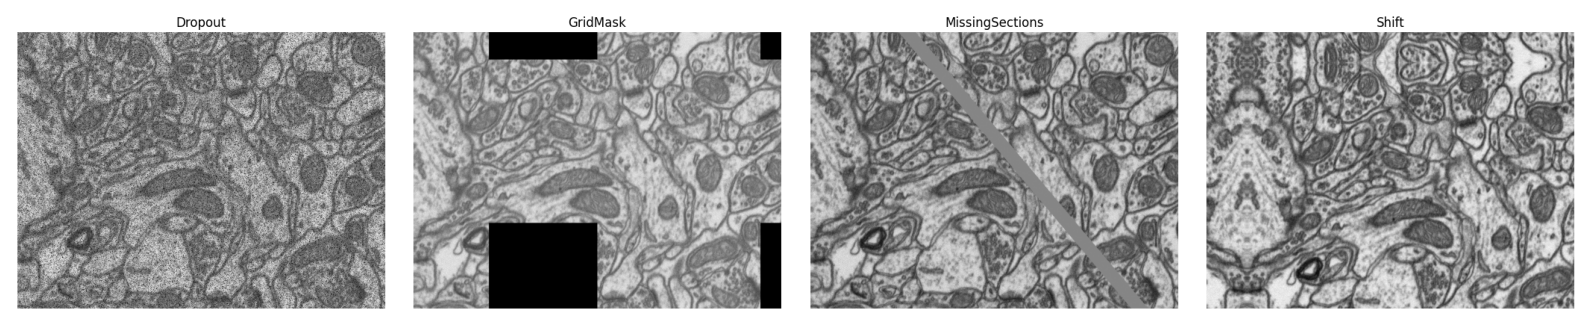

_(See “Experiments” below for all available transforms.)_

---


## **Install BiaPy**
---
This might take some minutes depending on the current installed libraries in Colab.


In [ ]:
#@markdown ##Play to install BiaPy and its dependences
# Install latest release of BiaPy
!pip install biapy==3.6.8

# Then install Pytorch
!pip install torch==2.9.1 torchvision

# Finally install some packages that rely on the Pytorch installation
!pip install timm==1.0.14 pytorch-msssim torchmetrics[image]==1.4.*


import os
import sys
import numpy as np
from tqdm.notebook import tqdm
from skimage.io import imread
import ipywidgets as widgets
from ipywidgets import Output
from biapy import BiaPy

changed_source = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.5/434.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.7/174.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.3/210.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━

## **Manage File(s) Source**
---

The input folder can be provided using three different options:
1. **Direct Upload**: Directly upload the desired folder.
2. **Google Drive**: Use a folder stored in your Google Drive.
3. **Sample Data**: Use a sample dataset provided by us.

The steps you'll need to follow vary depending on your chosen option. These steps are detailed in the subsequent sections.


### **Option 1: Upload Local Files to the Notebook**
---

You will be prompted to upload your files to Colab and they will be stored under `/content/input/`.

In [ ]:
#@markdown ##Play the cell to upload local files (test raw images)
from google.colab import files
import os
input_dir = '/content/input/test/raw'

if os.path.exists(input_dir):
    # Ask the user if they want to delete the existing items in the folder
    delete_items = ''
    while not delete_items in ['y', 'n']:
        delete_items = input("Do you want to delete the existing items in the folder? (yes[y]/no[n]): ").strip().lower()
    if delete_items == 'y':
        for delete_root, delete_dirs, delete_files in os.walk(input_dir, topdown=False):
            for name in delete_files:
                os.unlink(os.path.join(delete_root, name))
else:
    # Ensure the directory exists
    os.makedirs(input_dir, exist_ok=True)


%cd {input_dir}
uploaded = files.upload()
%cd /content

In [ ]:
#@markdown ##Play the cell to upload local files (test label images)

from google.colab import files
import os
input_dir = '/content/input/test/label'

if os.path.exists(input_dir):
    # Ask the user if they want to delete the existing items in the folder
    delete_items = ''
    while not delete_items in ['y', 'n']:
        delete_items = input("Do you want to delete the existing items in the folder? (yes[y]/no[n]): ").strip().lower()
    if delete_items == 'y':
        for delete_root, delete_dirs, delete_files in os.walk(input_dir, topdown=False):
            for name in delete_files:
                os.unlink(os.path.join(delete_root, name))
else:
    # Ensure the directory exists
    os.makedirs(input_dir, exist_ok=True)


%cd {input_dir}
uploaded = files.upload()
%cd /content

### **Option 2: Mount Your Google Drive**
---

If you wish to use this notebook with data from your Google Drive, you'll first need to mount the drive to this notebook.

Execute the cell below to initiate the Google Drive mounting process. A link will be displayed click on it. In the new browser window that opens, choose your drive and click 'Allow'. Copy the code that appears, return to this notebook, paste the code into the cell, and press 'Enter'. This action grants Colab access to your Google Drive data.

After this process, you can access your data via the **Files** tab, located on the top left of this notebook.

In [ ]:
#@markdown ##Play the cell to connect your Google Drive to Colab

#@markdown * Click on the URL.

#@markdown * Sign in your Google Account.

#@markdown * Copy the authorization code.

#@markdown * Enter the authorization code.

#@markdown * Click on "Files" site on the right. Refresh the site. Your Google Drive folder should now be available here as "drive".

# mount user's Google Drive to Google Colab.
from google.colab import drive
drive.mount('/content/gdrive')

### **Option 3: Download an Example Dataset**
---
Don't have data readily available but still want to test the notebook? No problem! Simply execute the following cell to download a sample dataset.

Specifically, we'll use the [Electron Microscopy Dataset (EPFL - CVLAB)](https://www.epfl.ch/labs/cvlab/data/data-em/) which is publicly available online.

In [ ]:
#@markdown ##Play to download an example dataset
!pip install gdown==5.1.0 --quiet
import gdown
import os

os.chdir('/content/')
gdown.download("https://drive.google.com/uc?id=1DfUoVHf__xk-s4BWSKbkfKYMnES-9RJt", "fibsem_epfl.zip", quiet=True)

!unzip -q fibsem_epfl.zip
!rm fibsem_epfl.zip

print( 'Dataset downloaded and unzipped under /content/data')


Dataset downloaded and unzipped under /content/data


## **Paths for Input Images and Output Files**
___

Depending on the option you chose for managing file sources, you'll set your paths differently:

- **Option 1 (Upload from Local Machine)**:
  - Set `test_data_path` to `/content/input/test/raw`
  - Set `test_data_gt_path` to `/content/input/test/label`
  
- **Option 2 (Use Google Drive Data)**:
  - Insert the paths to your input files and your desired output directory here, i.e., `/content/gdrive/MyDrive/...`.
  
- **Option 3 (Use Our Sample Data)**:
  - Set `test_data_path` to `/content/data/test/raw`
  - Set `test_data_gt_path` to `/content/data/test/label`

**Helpful Tip**: If you're unsure about the paths to your folders, look at the top left of this notebook for a small folder icon. Navigate through the directories until you locate your desired folder. Right-click on it and select "Copy Path" to copy the folder's path.

In [ ]:
#@markdown #####Path to test raw images
test_data_path = '/content/data/test/raw' #@param {type:"string"}
#@markdown #####Path to test label images (if available)
test_data_gt_path = '/content/data/test/label' #@param {type:"string"}

import os
from pathlib import Path

def count_image_files(directory):
    if not directory or not os.path.exists(directory):
        return 0
    image_extensions = {'.jpg', '.jpeg', '.png', '.tif', '.npy', '.tiff', '.h5', '.hd5', '.zarr'}
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if Path(file).suffix.lower() in image_extensions:
                count += 1
    return count

num_test_images = count_image_files(test_data_path)
num_test_labels = count_image_files(test_data_gt_path)

print(f"Number of test raw images: {num_test_images}")
if test_data_gt_path != "":
    print(f"Number of test label images: {num_test_labels}")

if test_data_gt_path != "" and num_test_images != num_test_labels:
    print("Error: The number of test raw images does not match the number of test label images.")

Number of test raw images: 165
Number of test label images: 165


## **Dataset Visualization**
___

In [ ]:
# @markdown ## Play to visualize some data samples
# @markdown Use the *Image index* scroll to navigate among samples.

# @markdown **Note**: it might take a few seconds to refresh the images.
%matplotlib inline
import matplotlib
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
import os
from ipywidgets import interact, IntSlider, Layout, Dropdown, HBox, Output

# Initialize paths and image IDs
input_path = test_data_path
gt_path = test_data_gt_path

ids_input = sorted(next(os.walk(input_path))[2])
ids_gt = sorted(next(os.walk(gt_path))[2])

# Slider widget to choose instance
slider= IntSlider(
    value=0,
    min=1,
    max=len(ids_input),
    step=1,
    description='Image index:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    layout=Layout(width='500px', margin = '0 0 0 10px')
)

slider.style.description_width = 'initial'
slider.style.handle_color='blue'

# Initialize Output instance to handle code output cell
output = Output()

# Function to update paths and image IDs (input_path, gt_path, ids_input, ids_gt) depending on dropdown
def update_paths(change):
    global input_path, gt_path
    input_path = test_data_path
    gt_path = test_data_gt_path

    global ids_input, ids_gt
    ids_input = sorted(next(os.walk(input_path))[2])

    try:
        ids_gt = sorted(next(os.walk(gt_path))[2])
    except StopIteration:
        ids_gt = []

    # Reset slider value to 1 when dropdown changes
    slider.value = 1
    slider.max = len(ids_input)
    display_images({'new': 1})

# Function to display images depending on slider value
def display_images(change):
    with output:
        output.clear_output(wait=True)
        index = change['new']

        global input_path, ids_input, gt_path, ids_gt
        input_img_path = os.path.join(input_path, ids_input[index-1])
        input_img = imread(input_img_path)
        input_img = np.squeeze(input_img)

        # # Print image path to ensure the image displayed is correct
        # print(input_img_path)

        # Display images
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title(f"Input image: {index}")
        if input_img.ndim == 2:
            plt.imshow(input_img, cmap='gray')
        else:
            plt.imshow(input_img)
        # plt.axis('off')

        if ids_gt != []: # If StopIteration exception was not thrown
            gt_img_path = os.path.join(gt_path, ids_gt[index-1])
            gt_img = imread(gt_img_path).astype(np.uint16)

            plt.subplot(1, 2, 2)
            plt.title("Label image")
            plt.imshow(np.squeeze(gt_img), cmap='gray', interpolation='nearest')
            # plt.axis('off')

            # # Print label path to ensure the image displayed is correct
            # print(gt_img_path)
        else:
            print("No labels for this set.")

        plt.show()
        print(f"Input image path: {input_img_path}")
        print(f"Label image path: {gt_img_path}")


# Create an HBox to hold the dropdown and slider
controls = HBox([slider])
display(controls, output)

# Link widgets to functions
slider.observe(display_images, names='value')

# Initial display
display_images({'new': slider.value})



Output()

## **Preprocess and Normalize dataset**
___


In [ ]:
#@markdown ##Play to load dataset
import numpy as np
from biapy.config.config import Config
from biapy.data.data_manipulation import load_data_from_dir
from biapy.data.norm import Normalization
from biapy.data.dataset import BiaPyDataset, DataSample, DatasetFile
from biapy.data.generators import Pair2DImageDataGenerator


# Get default config
cfg = Config(job_dir='./aug/', job_identifier='Experiment')
cfg = cfg.get_cfg_defaults()

# set data path and patch size
cfg.DATA.TEST.PATH = test_data_path
cfg.DATA.TEST.GT_PATH = test_data_gt_path

input_img_path = os.path.join(input_path, ids_input[0])
input_img = imread(input_img_path)

cfg.DATA.PATCH_SIZE = input_img.shape

# preprocessing base configuration
prep_cfg = cfg.DATA.PREPROCESS

# load data
X_test = load_data_from_dir(cfg.DATA.TEST.PATH, is_3d=False)
Y_test = load_data_from_dir(cfg.DATA.TEST.GT_PATH, is_3d=False)

if len(X_test) != len(Y_test):
    raise ValueError("Different number of raw and ground truth items ({} vs {}). "
        "Please check the data!".format(len(X_test), len(Y_test)))

x1,y1 = X_test[0], Y_test[0]

Loading images from /content/data/test/raw . . .


100%|██████████| 165/165 [00:00<00:00, 574.95it/s]


Loading images from /content/data/test/label . . .


100%|██████████| 165/165 [00:00<00:00, 532.62it/s]


In [ ]:
#@markdown ##Play to load utilities
%matplotlib inline
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Output
import numpy as np
import random

class QuietPair2DImageDataGenerator(Pair2DImageDataGenerator):
    def __init__(self, *args, **kwargs):
        import sys, io
        orig = sys.stdout
        sys.stdout = io.StringIO()
        super().__init__(*args, **kwargs)
        sys.stdout = orig

def create_generator(x_dataset, y_dataset, norm_module, image_shape, resolution, **augmentations):
    return QuietPair2DImageDataGenerator(
        ndim=2, X=x_dataset, Y=y_dataset,
        norm_module=norm_module, da=True, da_prob=1.0,
        shape=image_shape, resolution=resolution,
        **augmentations
    )

def plot_images(display_list, title=None, custom_size=False,
                save_fig_path='', mode='gray', vmin=0, vmax=1):
    n = len(display_list)
    if not custom_size:
        plt.figure(figsize=(12, 10))

    for i, img in enumerate(display_list):
        ax = plt.subplot(2, n//2, i + 1)
        ax.imshow(np.squeeze(img), cmap=mode, vmin=vmin, vmax=vmax)
        if title:
            ax.set_title(title[i])

        ax.set_xticks([])
        ax.set_yticks([])

    if save_fig_path:
        plt.savefig(save_fig_path)
    else:
        plt.show()

def show_augmented_slider(generator, X, y, config_name="Augmentation",
                          grid=False, max_visualizations=10):
    """
    Visualize original and augmented images with a slider,
    caching each aug sample so it stays fixed per index.
    """
    num_max = min(max_visualizations, len(X.sample_list))
    sampled_indices = sorted(random.sample(range(len(generator)), num_max))
    cache = [generator[i] for i in sampled_indices]
    output = Output()

    def plot(idx):
        sample_idx = sampled_indices[idx-1]  # actual data index
        x0 = norm_module.apply_image_norm(X.sample_list[sample_idx].img)[0]
        y0 = norm_module.apply_image_norm(y.sample_list[sample_idx].img)[0]
        aug_x, aug_y = cache[idx-1]  # now matches cached list
        imgs = [x0, y0, aug_x.numpy(), aug_y.numpy()]
        titles = ['Original Image', 'Original Mask',
                  f'{config_name} Image', f'{config_name} Mask']
        with output:
            output.clear_output(wait=True)
            plot_images([np.squeeze(im) for im in imgs],
                        title=titles)

    slider = IntSlider(min=1, max=num_max, step=1, description="Sample")
    interact(plot, idx=slider)
    display(output)


def bake_grid_into_dataset_pair(X_ds, Y_ds, norm_module, rows=6, cols=6, color=1.0):
    """
    Returns new datasets with grids baked into the images of both X_ds and Y_ds (before augmentation).
    """
    import cv2

    def bake_grid(dataset):
        baked_images = []
        for sample in dataset.sample_list:
            img = sample.img

            h, w, c = img.shape
            # Draw horizontal lines
            for r in range(1, rows):
                y = int(r * h / rows)
                cv2.line(img, (0, y), (w, y), int(color * 255), 3)
            # Draw vertical lines
            for c in range(1, cols):
                x = int(c * w / cols)
                cv2.line(img, (x, 0), (x, h), int(color * 255), 3)

            # Normalize back to float32 [0, 1]
            baked_images.append(img)

        info = [DatasetFile(path=f"grid_{i}", shape=img.shape) for i, img in enumerate(baked_images)]
        samples = [DataSample(i, None, img=img) for i, img in enumerate(baked_images)]
        return BiaPyDataset(info, samples)

    X_baked = bake_grid(X_ds)
    Y_baked = bake_grid(Y_ds)

    return X_baked, Y_baked


In [ ]:
#@markdown ##Play to prepare data
from copy import deepcopy
# 2. Prepare the data
X_dataset_info = [DatasetFile(path=f'X_img_{i}', shape=img.shape) for i, img in enumerate(X_test)]
Y_dataset_info = [DatasetFile(path=f'Y_img_{i}', shape=img.shape) for i, img in enumerate(Y_test)]

x_sample_list = [DataSample(i, None, img=img) for i, img in enumerate(X_test)]
y_sample_list = [DataSample(i, None, img=img) for i, img in enumerate(Y_test)]

X_ds = BiaPyDataset(X_dataset_info, x_sample_list)
Y_ds = BiaPyDataset(Y_dataset_info, y_sample_list)

# 4. Create a Normalization object
norm_module = Normalization(type='div', measure_by="image", mask_norm="none", out_dtype="float32", percentile_clip="")
resolution = (1.0, 1.0)

# 5. Create Grid in dataset
X_baked, y_baked = bake_grid_into_dataset_pair(deepcopy(X_ds), deepcopy(Y_ds), norm_module, rows=6, cols=6, color=1.0)

## **Experimenting**
___

Here, we explore and visualize the distinct augmentations applied to our dataset. This allows us to better understand how each transformation affects the input data.

### Cutout
---
Fills one or more rectangular areas in an image with a constant value.

**Arguments**
- `cutout` (`bool`): enable cutout.
- `cout_nb_iterations` (`tuple[int, int]`): number of rectangular areas to cut out, chosen randomly between these integers.
- `cout_size` (`tuple[float, float]`): range for width and height of cutout rectangles, specified as fractions of the image dimension (e.g., 0.1 = 10% of image width/height).
- `cout_cval` (`int`): value to fill the areas with.
- `cout_apply_to_mask` (`bool`): whether to apply cutout to the mask as well.

  

In [ ]:
# --- CUTOUT ---
#@markdown ## Cutout configuration
cutout = True #@param {type:"boolean"}
cout_nb_iterations = (1, 2) #@param
cout_size = (0.1, 0.3) #@param
cout_cval = 0 #@param {type:"integer"}
cout_apply_to_mask = True #@param {type:"boolean"}

cutout_config = {
    "cutout": cutout,
    "cout_nb_iterations": cout_nb_iterations,
    "cout_size": cout_size,
    "cout_cval": cout_cval,
    "cout_apply_to_mask": cout_apply_to_mask,
}

In [ ]:
from re import X
#@markdown ## Cutout Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **cutout_config)
show_augmented_slider(generator, X_to_use, y_to_use, config_name="Cutout", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Cutblur
---
Blurs a rectangular area of the image by downsampling and upsampling it.

**Arguments**
- `cutblur` (`bool`): enable cutblur.
- `cblur_size` (`tuple[float, float]`): range for the size of the area to blur, as a percentage of image size.
- `cblur_down_range` (`tuple[int, int]`): integer downsampling factors for the blur operation (e.g., 2 means downsample by 2x)
- `cblur_inside` (`bool`): If True, blur is applied inside the selected patch. If False, 50% chance to apply blur outside the patch (inverts low/high resolution regions).


In [ ]:
# --- CUTBLUR ---
#@markdown ## Cutblur configuration
cutblur = True #@param {type:"boolean"}
cblur_size = (0.1, 0.9) #@param
cblur_down_range = (2, 8) #@param
cblur_inside = True #@param {type:"boolean"}

cutblur_config = {
    "cutblur": cutblur,
    "cblur_size": cblur_size,
    "cblur_inside": cblur_inside,
    "cblur_down_range": cblur_down_range,
}

In [ ]:
#@markdown ## Cutblur Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **cutblur_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Cutblur", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Cutmix
---
Combines two images by pasting a region of one image into another.

**Arguments**
- `cutmix` (`bool`): enable cutmix.
- `cmix_size` (`tuple[float, float]`): range for the size of the area to paste, as a percentage of image size.


In [ ]:
# --- CUTMIX ---
#@markdown ## Cutmix configuration
cutmix = True #@param {type:"boolean"}
cmix_size = (0.1, 0.9) #@param

cutmix_config = {
    "cutmix": cutmix,
    "cmix_size": cmix_size,
}

In [ ]:
#@markdown ## Cutmix Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **cutmix_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Cutmix", grid=Plot_Grid)


interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### CutNoise
---
Adds Gaussian noise to a random cuboid region in the image.

**Arguments**
- `cutnoise` (`bool`): enable cutnoise.
- `cnoise_scale` (`tuple[float, float]`): range for the noise standard deviation, as a percentage of the image's max value.
- `cnoise_nb_iterations` (`tuple[int, int]`): range for the number of noisy areas to create.
- `cnoise_size` (`tuple[float, float]`): range for the size of the areas, as a percentage of image size.


In [ ]:
# --- CUTNOISE ---
#@markdown ## CutNoise configuration
cutnoise = True #@param {type:"boolean"}
cnoise_size = (0.3, 0.5) #@param
cnoise_nb_iterations = (1,5) #@param
cnoise_scale = (0.45, 0.5) #@param

cutnoise_config = {
    "cutnoise": cutnoise,
    "cnoise_size": cnoise_size,
    "cnoise_scale": cnoise_scale,
    "cnoise_nb_iterations": cnoise_nb_iterations,
}

In [ ]:
#@markdown ## CutNoise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **cutnoise_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="CutNoise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Misalignment
---
Introduces misalignments between image slices, simulating artifacts from serial section imaging.

**Arguments**
- `misalignment` (`bool`): enable misalignment.
- `ms_displacement` (`int`): maximum pixel displacement in x and y within each slice.
- `ms_rotate_ratio` (`float`): ratio of rotation-based misalignment.


In [ ]:
# --- MISALIGNMENT ---
#@markdown ## Misalignment configuration
misalignment = True #@param {type:"boolean"}
ms_displacement = 16 #@param
ms_rotate_ratio = 0.5 #@param

misalignment_config = {
    "misalignment": misalignment,
    "ms_displacement": ms_displacement,
    "ms_rotate_ratio": ms_rotate_ratio,
}

In [ ]:
#@markdown ## Misalignment Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **misalignment_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Misalignment", grid=Plot_Grid)


interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Brightness
---
Adjusts the brightness of the image.

**Arguments**
- `brightness` (`bool`): enable brightness adjustment.
- `brightness_factor` (`tuple[float, float]`): range for the brightness adjustment strength.
- `brightness_mode` (`str`): applies the change to the whole image (`'image'`) or slice by slice (`'slice'`).




In [ ]:
# --- BRIGHTNESS ---
#@markdown ## Brightness configuration
brightness = True #@param {type:"boolean"}
brightness_factor = (-0.3, 0.3) #@param
brightness_mode = "image"  #@param ["image", "slice"]

brightness_config = {
    "brightness": brightness,
    "brightness_factor": brightness_factor,
    "brightness_mode": brightness_mode,
}

In [ ]:
#@markdown ## Brightness Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **brightness_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Brightness", grid=Plot_Grid)


interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Contrast
---
Adjusts the contrast of the image.

**Arguments**
- `contrast` (`bool`): enable contrast adjustment.
- `contrast_factor` (`tuple[float, float]`): range for the contrast adjustment strength.
- `contrast_mode` (`str`): applies the change to the whole image (`'image'`) or slice by slice (`'slice'`).




In [ ]:
# --- CONTRAST ---
#@markdown ## Contrast configuration
contrast = True #@param {type:"boolean"}
contrast_factor = (-0.3, 0.3) #@param
contrast_mode = "image"  #@param ["image", "slice"]

contrast_config = {
    "contrast": contrast,
    "contrast_factor": contrast_factor,
    "contrast_mode": contrast_mode
}

In [ ]:
#@markdown ## Contrast Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **contrast_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Contrast", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Missing Sections
---
Simulates missing sections by creating a black line in a random position.**` (3D only)`**

**Arguments**
- `missing_sections` (`bool`): enable missing sections.
- `missp_iterations` (`tuple[int, int]`): range for the thickness of the missing line.
- `missp_iterations` (`float`): Probability of aplying missing sections to each channel.

In [ ]:
# --- MISSING SECTIONS ---
#@markdown ## Missing Sections configuration
missing_sections = True #@param {type:"boolean"}
missp_iterations = (30, 40) #@param
missp_channel_pb = 1.0 #@param

missing_sections_config = {
    "missing_sections": missing_sections,
    "missp_iterations": missp_iterations,
    "missp_channel_pb": missp_channel_pb,
}

In [ ]:
#@markdown ## Missing Sections Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **missing_sections_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Missing Sections", grid=Plot_Grid)


interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Shuffle Channels
---
Randomly shuffles the color channels of the image.

**Arguments**
- `channel_shuffle` (`bool`): enable channel shuffle.




In [ ]:
# --- SHUFFLE CHANNELS ---
#@markdown ## Shuffle Channels configuration
channel_shuffle = True #@param {type:"boolean"}

channel_shuffle_config = {
    "channel_shuffle": channel_shuffle,
}

In [ ]:
#@markdown ## Shuffle Channels Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **channel_shuffle_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Shuffle Channels", grid=Plot_Grid)


interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### GridMask
---
Applies a grid-like mask to the image, dropping out regions.

**Arguments**
- `gridmask` (`bool`): enable GridMask.
- `grid_ratio` (`float`): determines the keep ratio of the input image.
- `grid_d_range` (`tuple[float, float]`): range for the size of the grid cells, as a percentage of image size.
- `grid_rotate` (`float`): rotation of the mask, where 1.0 is 360 degrees.
- `grid_invert` (`bool`): whether to invert the mask.

In [ ]:
# --- GRIDMASK ---
#@markdown ## GridMask configuration
gridmask = True #@param {type:"boolean"}
grid_d_range = (0.1, 0.2) #@param
grid_ratio = 0.6 #@param
grid_rotate = 1 #@param
grid_invert = False #@param {type:"boolean"}

gridmask_config = {
    "gridmask": gridmask,
    "grid_d_range": grid_d_range,
    "grid_ratio": grid_ratio,
    "grid_rotate": grid_rotate,
    "grid_invert": grid_invert,
}

In [ ]:
#@markdown ## GridMask Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **gridmask_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="GridMask", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Random Rotation  
---
Rotate by fixed‐angle multiples or random angles.

**Arguments**  
- `rand_rot` (`bool`): rotate by random angle  
- `rnd_rot_range` (`tuple[float, float]`): random angle sampled uniformly e.g. between -45° and 45°."
- `affine_mode` (`str`): how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric' and 'reflect'

In [ ]:
# --- Random Rotation ---
#@markdown ## Random Rotation configuration
rand_rot = True #@param {type:"boolean"}
rnd_rot_range = (-180, 180) #@param
affine_mode = "reflect"  #@param ["symmetric", "constant", "reflect", "wrap", "edge"]


# --- Configure augmentations ---
random_rot_config = {
    "rand_rot": rand_rot,
    "rnd_rot_range": rnd_rot_range,
    "affine_mode": affine_mode
}

In [ ]:
#@markdown ## Random Rotation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **random_rot_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="RandomRotation", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### 90 Degree Rotation  
---
Rotate by fixed‐angle multiples or random angles.

**Arguments**  
- `rotation90` (`bool`): rotate by 90-180-270  
- `affine_mode` (`str`): how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric' and 'reflect'

In [ ]:
# --- 90 Degree Rotation ---
#@markdown ## 90 Degree Rotation configuration
rotation90 = True #@param {type:"boolean"}
affine_mode = "reflect"  #@param ["symmetric", "constant", "reflect", "wrap"]

# --- Configure augmentations ---
rot_90_config = {
    "rotation90": True,
    "affine_mode": affine_mode
}

In [ ]:
#@markdown ## 90 Degree Rotation Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **rot_90_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Rotation90", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Zoom  
---
Randomly zooms in/out.

**Arguments**  
- `zoom` (`bool`): enable zoom  
- `zoom_range` (`tuple[float, float]`):range of zoom scaling factors, e.g., 0.8 (zoom out) to 1.2 (zoom in).
- `affine_mode` (`str`): how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric' and 'reflect'
- `zoom_in_z` (`bool`): (3D only) whether to zoom along Z axis  


In [ ]:
# --- Zoom ---
#@markdown ## Zoom configuration
zoom = True #@param {type:"boolean"}
zoom_range = (0.4, 1.5)  #@param
affine_mode = "reflect"  #@param ["symmetric", "constant", "reflect", "wrap", "edge"]
zoom_in_z = False #@param {type:"boolean"}

# --- Configure augmentations ---
zoom_config = {
    "zoom": True,
    "zoom_range": zoom_range,
    "zoom_in_z": zoom_in_z,
    "affine_mode": affine_mode
}

In [ ]:
#@markdown ## Zoom Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **zoom_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Zoom", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Gamma Contrast
---
Adjusts image contrast using a gamma correction.

**Arguments**
- `gamma_contrast` (`bool`): enable gamma contrast.
- `gc_gamma` (`tuple[float, float]`): exponent for the contrast adjustment. Higher values darken the image.




In [ ]:
# --- Gamma Contrast ---
#@markdown ## Gamma Contrast configuration
gamma_contrast = True #@param {type:"boolean"}
gc_gamma = (1.5, 1.9)  #@param

# --- Configure augmentations ---
gamma_contrast_config = {
    "gamma_contrast": gamma_contrast,
    "gc_gamma": gc_gamma
}

In [ ]:
#@markdown ## Gamma Contrast Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **gamma_contrast_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="GammaContrast", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Shear
---
Applies a shear transformation to the image.

**Arguments**
- `shear` (`bool`): enable shear.
- `shear_range` (`tuple[int, int]`): degree range for the shear, e.g., `(-20, 20)`.
- `affine_mode` (`str`): how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric' and 'reflect'

In [ ]:
# --- Shear ---
#@markdown ## Shear configuration
shear = True #@param {type:"boolean"}
shear_range = (-20, 20) #@param
affine_mode = "reflect"  #@param ["symmetric", "constant", "reflect", "wrap", "edge"]


# --- Configure augmentations ---
shear_config = {
    "shear": shear,
    "shear_range": shear_range,
    "affine_mode": affine_mode
}

In [ ]:
#@markdown ## Shear Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **shear_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Shear", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Shift
---
Shifts the image horizontally and vertically.

**Arguments**
- `shift` (`bool`): enable shift.
- `shift_range` (`tuple[float, float]`): range for the shift, as a fraction of image size, e.g., `(0.1, 0.2)`.
- `affine_mode` (`str`): how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric' and 'reflect'


In [ ]:
# --- Shift ---
#@markdown ## Shift configuration
shift = True #@param {type:"boolean"}
shift_range = (0.1, 0.2) #@param
affine_mode = "reflect"  #@param ["symmetric", "constant", "reflect", "wrap"]

# --- Configure augmentations ---
shift_config = {
    "shift": shift,
    "shift_range": shift_range,
    "affine_mode": affine_mode
}

In [ ]:
#@markdown ## Shift Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **shift_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Shift", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Horizontal Flip
---
Flips the image horizontally
  **Arguments**
  - `hflip` (`bool`): enable horizontal flip.

In [ ]:
# --- Horizontal Flip ---
#@markdown ## Horizontal Flip configuration
hflip = True #@param {type:"boolean"}

# --- Configure augmentations ---
h_flip_config = {
    "hflip": hflip
}

In [ ]:
#@markdown ## HorizontalFlip Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **h_flip_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="HorizontalFlip", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Vertical Flip
---
Flips the image vertically
**Arguments**
- `vflip` (`bool`): enable vertical flip.



In [ ]:
# --- Vertical Flip ---
#@markdown ## Vertical Flip configuration
vflip = True #@param {type:"boolean"}

# --- Configure augmentations ---
v_flip_config = {
    "vflip": vflip
}

In [ ]:
#@markdown ## VerticalFlip Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **v_flip_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="VerticalFlip", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Gaussian Blur
---
Applies a Gaussian blur to the image.

**Arguments**
- `g_blur` (`bool`): enable Gaussian blur.
- `g_sigma` (`tuple[float, float]`): range for the standard deviation for Gaussian kernel in pixels.


In [ ]:
# --- Gaussian Blur ---
#@markdown ## Gaussian Blur configuration
g_blur = True #@param {type:"boolean"}
g_sigma = (1.4, 3.0) #@param


# --- Configure augmentations ---
gaussian_config = {
    "g_blur": g_blur,
    "g_sigma":  g_sigma
}


In [ ]:
#@markdown ## Gaussian Blur Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **gaussian_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="GaussianBlurred", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Median Blur
---
Blurs the image by computing the median value over a neighborhood.

**Arguments**
- `median_blur` (`bool`): enable median blur.
- `mb_kernel` (`tuple[int, int]`): range for the median blur kernel size.



In [ ]:
# --- Median Blur ---
#@markdown ## Median Blur configuration
median_blur = True #@param {type:"boolean"}
mb_kernel = (3, 7) #@param


# --- Configure augmentations ---
median_blur_config = {
    "median_blur": median_blur,
    "mb_kernel":  mb_kernel
}

In [ ]:
#@markdown ## Median Blur Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **median_blur_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="MedianBlurred", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Motion Blur
---
Blurs the image to simulate camera or object movement.

**Arguments**
- `motion_blur` (`bool`): enable motion blur.
- `motb_k_range` (`tuple[int, int]`): range for the kernel size to use in motion blur.


In [ ]:
# --- Motion Blur ---
#@markdown ## Motion Blur configuration
motion_blur = True #@param {type:"boolean"}
motb_k_range = (8, 12) #@param

# --- Configure augmentations ---
motion_blur_config = {
    "motion_blur": motion_blur,
    "motb_k_range":  motb_k_range
}

In [ ]:
#@markdown ## Motion Blur Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **motion_blur_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="MotionBlurred", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Poisson Noise
---
Adds Poisson-distributed noise to the image.

**Arguments**
- `poisson_noise` (`bool`): enable Poisson noise.

In [ ]:
# --- Poisson Noise  ---
#@markdown ## Poisson Noise  configuration
poisson_noise = True #@param {type:"boolean"}

# --- Configure augmentations ---
poisson_config = {
    "poisson_noise": poisson_noise,
}

In [ ]:
#@markdown ## Poisson Noise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **poisson_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Poisson Noise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Gaussian Noise
---
Adds Gaussian-distributed noise to the image.

**Arguments**
- `Gaussian_noise` (`bool`): enable Gaussian noise.
- `Gaussian_noise_mean` (`float`): Gaussian noise mean.
- `Gaussian_noise_var` (`float`): Gaussian noise variance.
- `Gaussian_noise_use_input_img_mean_and_var` (`bool`): Use image mean and var.

In [ ]:
# --- Gaussian Noise  ---
#@markdown ## Gaussian Noise  configuration
gaussian_noise = True #@param {type:"boolean"}
gaussian_noise_mean = 0.0 #@param
gaussian_noise_var = 0.05 #@param
gaussian_noise_use_input_img_mean_and_var = False #@param {type:"boolean"}

# --- Configure augmentations ---
gaussian_config = {
"gaussian_noise" : gaussian_noise,
"gaussian_noise_mean" : gaussian_noise_mean,
"gaussian_noise_var" : gaussian_noise_var,
"gaussian_noise_use_input_img_mean_and_var" : gaussian_noise_use_input_img_mean_and_var,
}

In [ ]:
#@markdown ## Gaussian Noise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **gaussian_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Gaussian Noise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Salt Noise
---
Randomly replaces pixels with white (max value).

**Arguments**
- `salt` (`bool`): enable salt noise.
- `salt_amount` (`float`): proportion of pixels to replace.


In [ ]:
# --- Salt Noise  ---
#@markdown ## Salt Noise  configuration
salt = True #@param {type:"boolean"}
salt_amount = 0.05 #@param

# --- Configure augmentations ---
salt_config = {
    "salt": salt,
    "salt_amount": salt_amount  # n% of pixels will be set to white
}

In [ ]:
#@markdown ## Salt Noise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **salt_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Salt Noise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Pepper Noise
---
Randomly replaces pixels with black (min value).

**Arguments**
- `pepper` (`bool`): enable pepper noise.
- `pepper_amount` (`float`): proportion of pixels to replace.


In [ ]:
# --- Pepper Noise  ---
#@markdown ## Pepper Noise  configuration
pepper = True #@param {type:"boolean"}
pepper_amount = 0.05 #@param

# --- Configure augmentations ---
pepper_config = {
    "pepper": pepper,
    "pepper_amount": pepper_amount  # n% of pixels will be set to white
}

In [ ]:
#@markdown ## Pepper Noise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **pepper_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Pepper Noise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Salt-and-Pepper Noise
Randomly replaces pixels with either white or black.

**Arguments**
- `salt_and_pepper` (`bool`): enable salt-and-pepper noise.
- `salt_pep_amount` (`float`): fraction of total pixels to alter.
- `salt_pep_proportion` (`float`): proportion of salt (white) vs pepper (black), where 0.5 means equal amounts

In [ ]:
# --- Salt And Pepper Noise  ---
#@markdown ## Salt And Pepper Noise  configuration
salt_and_pepper = True #@param {type:"boolean"}
salt_pep_amount = 0.05 #@param
salt_pep_proportion = 0.5 #@param

# --- Configure augmentations ---
salt_pepper_config = {
    "salt_and_pepper": salt_and_pepper,
    "salt_pep_amount": salt_pep_amount,        # 5% of pixels will be affected
    "salt_pep_proportion": salt_pep_proportion     # 50% salt, 50% pepper
}

In [ ]:
#@markdown ## Salt And Pepper Noise Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **salt_pepper_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Salt/Pepper Noise", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Dropout
---
Randomly sets a fraction of pixels in the image to zero.

**Arguments**
- `dropout` (`bool`): enable dropout.
- `drop_range` (`tuple[float, float]`): range for the probability `p` of dropping a pixel.



In [ ]:
# --- Dropout  ---
#@markdown ## Dropout configuration
dropout = True #@param {type:"boolean"}
drop_range = (0.1, 0.2) #@param

# --- Configure augmentations ---
dropout_config = {
    "dropout": True,
    "drop_range": drop_range
}

In [ ]:
#@markdown ## Droppout Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **dropout_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Droppout", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()

### Elastic Deformation
---
Applies elastic deformations to the image.

**Arguments**
- `elastic` (`bool`): enable elastic deformation.
- `e_alpha` (`tuple[int, int]`): range for the intensity of the deformation field; higher means stronger distortion.
- `e_sigma` (`int`): standard deviation of the Gaussian kernel for smoothing, controls smoothness of deformation
- `e_mode` (`str`):  how pixels outside image boundaries are filled, options include 'constant', 'wrap', 'symmetric', and 'reflect'

In [ ]:
# --- Elastic ---
#@markdown ## Elastic configuration
elastic = True #@param {type:"boolean"}
e_alpha = (50, 55) #@param
e_sigma = 5 #@param
e_mode = "reflect"  #@param ["constant", "reflect", "symmetric", "wrap"]

# --- Configure augmentations ---
elastic_config = {
    "elastic": elastic,
    "e_alpha": e_alpha,
    "e_sigma": e_sigma,
    "e_mode": e_mode
}

In [ ]:
#@markdown ## Elastic Augmentation Visualization
Plot_Grid = True #@param {type:"boolean"}
if Plot_Grid:
  X_to_use, y_to_use = X_baked, y_baked
else:
  X_to_use, y_to_use = X_ds, Y_ds
generator = create_generator(X_to_use, y_to_use, norm_module, x1.shape, resolution, **elastic_config)
show_augmented_slider(generator,  X_to_use, y_to_use, config_name="Elastic", grid=Plot_Grid)

interactive(children=(IntSlider(value=1, description='Sample', max=10, min=1), Output()), _dom_classes=('widge…

Output()